In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

In [5]:
# ============================================================
# NOTEBOOK BLOCK: load linear-oscillator checkpoints, compute
# ground truth correctly, and plot pairwise comparisons
# ============================================================
# ----------------------------
# repo / imports
# ----------------------------
REPO_ROOT = Path("/home/kendra/Code/Learning_Value_Function_Manifold")
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from torchdiffeq import odeint

from lvfm.models import Decoder, PNODE, INR_PNODE, DeepReachModel, DeepReachExact
from lvfm.residuals import LinearOscillator2DResidual
from lvfm.managers import LossManager
from lvfm.hj_solvers import solve_linear_oscillator_2d

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ----------------------------
# run locations
# ----------------------------
RUN_ROOT = REPO_ROOT / "scripts" / "runs" / "linear_oscillator_2d"

CNFROM_RUNS = {
    "cnfrom_1": RUN_ROOT / "cnfrom_1",
    "cnfrom_2": RUN_ROOT / "cnfrom_2",
    "cnfrom_16": RUN_ROOT / "cnfrom_16",
    "cnfrom_128": RUN_ROOT / "cnfrom_128",
}

DEEPREACH_RUN = RUN_ROOT / "deepreach"

from pathlib import Path

OUTPUT_DIR = REPO_ROOT / "scripts" / "runs" / "linear_oscillator_2d" / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Saving outputs to:", OUTPUT_DIR)

# ----------------------------
# helpers
# ----------------------------
def to_namespace(d):
    return SimpleNamespace(**d)

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def load_cfg_from_run(run_dir):
    return to_namespace(load_yaml(Path(run_dir) / "config.yaml"))

def tau_ckpt_name(tau: float) -> str:
    if abs(float(tau)) < 1e-12:
        return "pretrain.pt"
    return f"tau_{float(tau):.2f}.pt"

def build_linear_residual(cfg):
    return LinearOscillator2DResidual(
        oscillation_speed=cfg.omega,
        control_bound=cfg.u_bound,
        disturbance_bound=cfg.d_bound,
        radius=cfg.beta,
        T=cfg.T,
        x1_bounds=cfg.x1_bounds,
        x2_bounds=cfg.x2_bounds,
        scale_to_minus1_1=cfg.scale_to_minus1_1,
        scale_time_to_01=cfg.scale_time_to_01,
    )

def build_cnfrom_model(cfg, device=DEVICE):
    residual = build_linear_residual(cfg)
    loss_manager = LossManager(
        residual=residual,
        loss_weights={"terminal": 1.0, "pinn": 1.0},
    )

    decoder = Decoder(
        hidden_dim=cfg.decoder_hidden_dim,
        latent_dim=cfg.latent_dim,
        coordinate_dim=cfg.coordinate_dim,
        out_dim=1,
        num_layers=cfg.decoder_num_layers,
        net_type=cfg.net_type,
        input_scale=getattr(cfg, "input_scale", 64.0),
        omega0=getattr(cfg, "omega0", 30.0),
    )

    pnode = PNODE(
        latent_dim=cfg.latent_dim,
        hidden_dim=cfg.pnode_hidden_dim,
        num_layers=getattr(cfg, "pnode_num_layers", 3),
        # omega0=getattr(cfg, "omega0", 15.0),
    )

    model = INR_PNODE(
        latent_dim=cfg.latent_dim,
        decoder=decoder,
        pnode=pnode,
        loss_manager=loss_manager,
        value_var=getattr(cfg, "value_var", 0.5),
        value_normto=getattr(cfg, "value_normto", 0.02),
        ode_solver=odeint,
        method=cfg.method,
        rtol=cfg.rtol,
        atol=cfg.atol,
        device=device,
    ).to(device)

    return model

def build_deepreach_model(cfg, wrapped=True, device=DEVICE):
    backbone = DeepReachModel(
        in_dim=cfg.in_dim,
        hidden_dim=cfg.hidden_dim,
        num_layers=cfg.num_layers,
        omega0=cfg.omega0,
    ).to(device)

    if not wrapped:
        return backbone

    residual = build_linear_residual(cfg)
    model = DeepReachExact(
        backbone=backbone,
        residual=residual,
        coordinate_dim=2,
        value_var=getattr(cfg, "value_var", 0.5),
        value_normto=getattr(cfg, "value_normto", 0.02),
    ).to(device)
    return model

def load_cnfrom_checkpoint(run_dir, ckpt_name, device=DEVICE):
    run_dir = Path(run_dir)
    cfg = load_cfg_from_run(run_dir)
    model = build_cnfrom_model(cfg, device=device)

    ckpt_path = run_dir / "ckpts" / ckpt_name
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()
    return model, cfg, ckpt

def load_deepreach_checkpoint(run_dir, ckpt_name, device=DEVICE):
    run_dir = Path(run_dir)
    cfg = load_cfg_from_run(run_dir)

    ckpt_path = run_dir / "ckpts" / ckpt_name
    ckpt = torch.load(ckpt_path, map_location=device)
    state_dict = ckpt["model_state_dict"]

    # saved from wrapped DeepReachExact
    if any(k.startswith("backbone.") for k in state_dict.keys()):
        model = build_deepreach_model(cfg, wrapped=True, device=device)
        model.load_state_dict(state_dict, strict=True)
    else:
        # saved from raw DeepReachModel
        model = build_deepreach_model(cfg, wrapped=False, device=device)
        model.load_state_dict(state_dict, strict=True)

    model.eval()
    return model, cfg, ckpt

def scale_states_to_net(x_phys, cfg):
    x = torch.tensor(x_phys, dtype=torch.float32)
    if getattr(cfg, "scale_to_minus1_1", True):
        x1_lo, x1_hi = cfg.x1_bounds
        x2_lo, x2_hi = cfg.x2_bounds
        x[:, 0] = 2.0 * (x[:, 0] - x1_lo) / (x1_hi - x1_lo) - 1.0
        x[:, 1] = 2.0 * (x[:, 1] - x2_lo) / (x2_hi - x2_lo) - 1.0
    return x

def scale_tau_to_net(tau, cfg, n):
    tau_vec = torch.full((n, 1), float(tau), dtype=torch.float32)
    if getattr(cfg, "scale_time_to_01", True):
        tau_vec = tau_vec / cfg.T
    return tau_vec

@torch.no_grad()
def evaluate_cnfrom_on_grid(model, cfg, tau, nx=201, device=DEVICE, chunk_size=4096):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)
    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    for start in range(0, xt.shape[0], chunk_size):
        end = min(start + chunk_size, xt.shape[0])
        xt_chunk = xt[start:end]
        tau_phys_chunk = torch.full((end - start,), float(tau), dtype=torch.float32, device=device)
        V_chunk = model.compute_value_at_xt(xt_chunk, tau_phys_chunk)[0]
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    return X1, X2, V_pred

@torch.no_grad()
def evaluate_deepreach_on_grid(model, cfg, tau, nx=201, device=DEVICE, chunk_size=4096):
    x1 = np.linspace(cfg.x1_bounds[0], cfg.x1_bounds[1], nx)
    x2 = np.linspace(cfg.x2_bounds[0], cfg.x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    pts_phys = np.stack([X1.reshape(-1), X2.reshape(-1)], axis=-1).astype(np.float32)
    x_net = scale_states_to_net(pts_phys, cfg)
    tau_net = scale_tau_to_net(tau, cfg, len(pts_phys))
    xt = torch.cat([x_net, tau_net], dim=-1).to(device)

    vals = []
    for start in range(0, xt.shape[0], chunk_size):
        end = min(start + chunk_size, xt.shape[0])
        xt_chunk = xt[start:end]
        V_chunk = model(xt_chunk)
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(nx, nx)
    return X1, X2, V_pred

def compute_ground_truth_slice(
    tau=1.0,
    nx=201,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    omega=1.0,
    u_bound=1.0,
    d_bound=0.5,
    beta=0.25,
):
    """
    Uses the same project solver as the training script.

    IMPORTANT:
    solve_linear_oscillator_2d([tau], ...) may return:
      [V(tau)]                OR
      [V(0), V(tau)]
    depending on the helper implementation.

    To be robust and to fix the tau=1.0 issue, we always take the LAST slice.
    """
    x1 = np.linspace(x1_bounds[0], x1_bounds[1], nx)
    x2 = np.linspace(x2_bounds[0], x2_bounds[1], nx)
    X1, X2 = np.meshgrid(x1, x2, indexing="xy")

    gt = solve_linear_oscillator_2d(
        [float(tau)],
        nx,
        nx,
        x1_bounds,
        x2_bounds,
        u_bound,
        d_bound,
        omega,
        beta,
    )

    # robust: use final returned slice, not gt[0]
    V = np.array(gt[-1]).T
    return X1, X2, V

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)

def compute_mae(V_pred, V_gt):
    return np.mean(np.abs(V_pred - V_gt))

def plot_pairwise_comparison(tau=1.00, nx=201, save=True):
    """
    Panels in a 2x3 grid:
      Row 1: LatentReach 1 | LatentReach 2 | LatentReach 16
      Row 2: LatentReach 128 | DeepReach | Ground Truth
    """

    cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(tau=tau, nx=nx)

    # Expecting:
    # LatentReach 1, LatentReach 2, LatentReach 16, LatentReach 128, DeepReach
    # plus Ground Truth as final panel

    fig, axes = plt.subplots(2, 3, figsize=(14, 9), constrained_layout=False)
    fig.subplots_adjust(hspace=0.05, wspace=0.6)
    axes = axes.flatten()

    # plot model panels
    for ax, (name, X1, X2, V) in zip(axes[:len(model_entries)], model_entries):
        vmin = np.nanmin(V)
        vmax = np.nanmax(V)
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6
        levels = np.linspace(vmin, vmax, 40)

        cf = ax.contourf(X1, X2, V, levels=levels)
        ax.contour(X1, X2, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(X1_gt, X2_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

        ax.set_title(name, fontsize=12)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_xlim(cfg_ref.x1_bounds)
        ax.set_ylim(cfg_ref.x2_bounds)
        ax.set_aspect("equal")

        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    # Ground truth in final panel
    gt_ax = axes[5]
    gt_vmin = np.nanmin(V_gt)
    gt_vmax = np.nanmax(V_gt)
    if np.isclose(gt_vmin, gt_vmax):
        gt_vmax = gt_vmin + 1e-6
    gt_levels = np.linspace(gt_vmin, gt_vmax, 40)

    cf = gt_ax.contourf(X1_gt, X2_gt, V_gt, levels=gt_levels)
    gt_ax.contour(X1_gt, X2_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

    gt_ax.set_title("Ground Truth", fontsize=12)
    gt_ax.set_xlabel(r"$x_1$")
    gt_ax.set_ylabel(r"$x_2$")
    gt_ax.set_xlim(cfg_ref.x1_bounds)
    gt_ax.set_ylim(cfg_ref.x2_bounds)
    gt_ax.set_aspect("equal")

    fig.colorbar(cf, ax=gt_ax, fraction=0.046, pad=0.03)

    # fig.suptitle(f"Linear oscillator comparison at $\\tau={tau:.2f}$", fontsize=16)

    if save:
        save_path = OUTPUT_DIR / f"pairwise_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

import pandas as pd

def compute_mse(V_pred, V_gt):
    return np.mean((V_pred - V_gt) ** 2)

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)
    
def evaluate_all_models_for_tau(tau=1.00, nx=201):
    """
    Returns:
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries
    where model_entries is a list of:
        (display_name, X1, X2, V)
    """

    _, cfg_ref, _ = load_cnfrom_checkpoint(
        CNFROM_RUNS["cnfrom_2"],
        tau_ckpt_name(min(float(tau), 1.00)),
        device=DEVICE,
    )

    X1_gt, X2_gt, V_gt = compute_ground_truth_slice(
        tau=tau,
        nx=nx,
        x1_bounds=cfg_ref.x1_bounds,
        x2_bounds=cfg_ref.x2_bounds,
        omega=cfg_ref.omega,
        u_bound=cfg_ref.u_bound,
        d_bound=cfg_ref.d_bound,
        beta=cfg_ref.beta,
    )

    model_entries = []

    latentreach_runs = [
        ("LatentReach 1", "cnfrom_1"),
        ("LatentReach 2", "cnfrom_2"),
        ("LatentReach 16", "cnfrom_16"),
        ("LatentReach 128", "cnfrom_128"),
    ]

    for display_name, run_key in latentreach_runs:
        run_dir = CNFROM_RUNS[run_key]
        ckpt_name = tau_ckpt_name(min(float(tau), 1.00))
        ckpt_path = run_dir / "ckpts" / ckpt_name
        if not ckpt_path.exists():
            ckpt_name = "tau_1.00.pt"

        model, cfg, _ = load_cnfrom_checkpoint(run_dir, ckpt_name, device=DEVICE)
        X1, X2, V = evaluate_cnfrom_on_grid(model, cfg, tau=tau, nx=nx, device=DEVICE)
        model_entries.append((display_name, X1, X2, V))

    deep_ckpt = DEEPREACH_RUN / "ckpts" / tau_ckpt_name(min(float(tau), 1.00))
    deep_ckpt_fallback = DEEPREACH_RUN / "ckpts" / "tau_1.00.pt"

    if deep_ckpt.exists():
        deep_ckpt_name = deep_ckpt.name
    elif deep_ckpt_fallback.exists():
        deep_ckpt_name = deep_ckpt_fallback.name
    else:
        deep_ckpt_name = None

    if deep_ckpt_name is not None:
        model, cfg, _ = load_deepreach_checkpoint(DEEPREACH_RUN, deep_ckpt_name, device=DEVICE)
        X1, X2, V = evaluate_deepreach_on_grid(model, cfg, tau=tau, nx=nx, device=DEVICE)
        model_entries.append(("DeepReach", X1, X2, V))

    return cfg_ref, X1_gt, X2_gt, V_gt, model_entries

def make_metrics_table(taus=[1.00], nx=201):
    rows = []

    for tau in taus:
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(tau=tau, nx=nx)

        for name, X1, X2, V in model_entries:
            rows.append({
                "tau": tau,
                "model": name,
                "MSE": compute_mse(V, V_gt),
                "IoU": compute_iou(V, V_gt),
            })

    df = pd.DataFrame(rows)
    return df

def plot_zero_level_overlay_row(
    taus=[0.05, 0.10, 0.20, 0.40, 0.70, 1.00],
    nx=401,
    save=True
):
    """
    Stacked BRT overlay figure in a 2x3 grid.
    Each panel shows the zero level set for all models plus ground truth.
    """

    colors = {
        "LatentReach 1": "tab:red",
        "LatentReach 2": "tab:green",
        "LatentReach 16": "tab:orange",
        "LatentReach 128": "tab:purple",
        "DeepReach": "tab:blue",
    }

    fig, axes = plt.subplots(
        2, 3,
        figsize=(14, 9),
        constrained_layout=False
    )
    axes = axes.flatten()

    # adjust spacing manually
    fig.subplots_adjust(hspace=0.15, wspace=0.35)

    legend_handles = [
        plt.Line2D([0], [0], color="black", lw=3.0, label="Ground Truth"),
        plt.Line2D([0], [0], color="tab:red", lw=2.0, label="LatentReach 1"),
        plt.Line2D([0], [0], color="tab:green", lw=2.0, label="LatentReach 2"),
        plt.Line2D([0], [0], color="tab:orange", lw=2.0, label="LatentReach 16"),
        plt.Line2D([0], [0], color="tab:purple", lw=2.0, label="LatentReach 128"),
        plt.Line2D([0], [0], color="tab:blue", lw=2.0, label="DeepReach"),
    ]

    for ax, tau in zip(axes, taus):
        cfg_ref, X1_gt, X2_gt, V_gt, model_entries = evaluate_all_models_for_tau(
            tau=tau, nx=nx
        )

        # ground truth
        ax.contour(
            X1_gt, X2_gt, V_gt,
            levels=[0.0],
            colors="black",
            linewidths=3.0
        )

        # models
        for name, X1, X2, V in model_entries:
            ax.contour(
                X1, X2, V,
                levels=[0.0],
                colors=colors[name],
                linewidths=2.0
            )

        ax.set_title(rf"$\tau={tau:.2f}$", fontsize=12)
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_aspect("equal")
        ax.set_xlim(cfg_ref.x1_bounds)
        ax.set_ylim(cfg_ref.x2_bounds)

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 0.98)
    )
    # fig.suptitle("BRT overlay across time", fontsize=16)

    if save:
        save_path = OUTPUT_DIR / "brt_overlay_row.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

DEVICE: cuda
Saving outputs to: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs


100%|##################################|  1.0000/1.0 [00:00<00:00,  1.33sim_s/s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/pairwise_tau_1.00.png


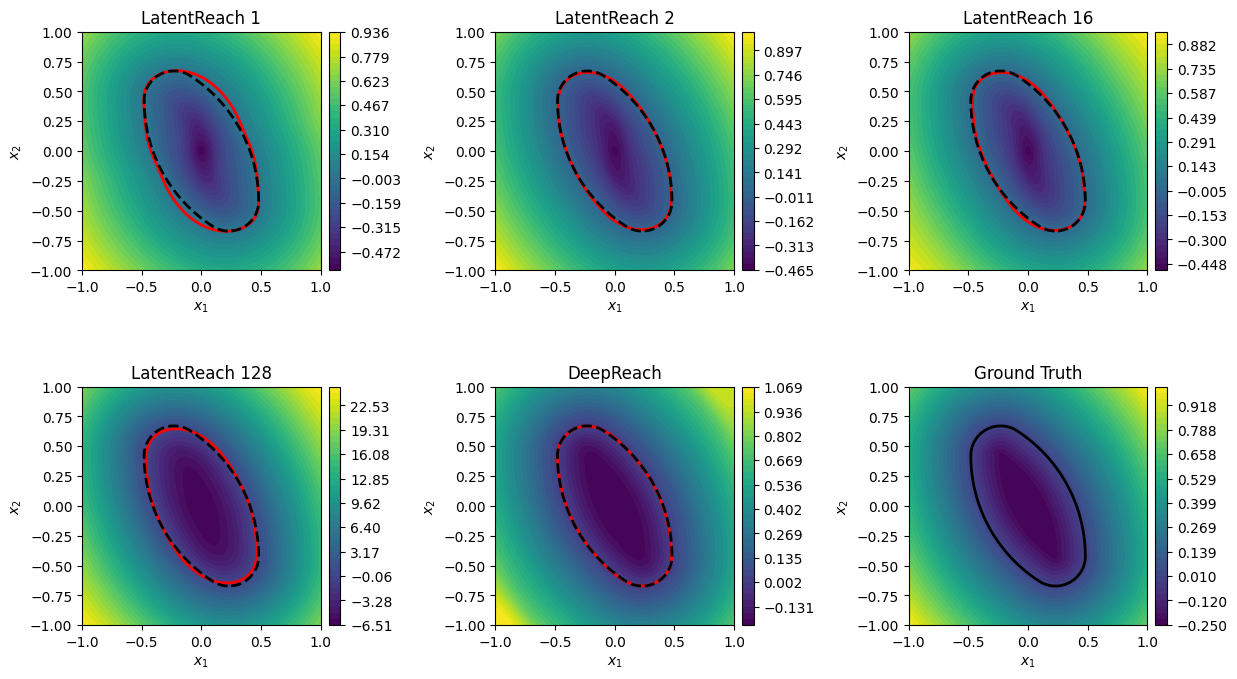

In [6]:
plot_pairwise_comparison(tau=1.00, nx=201)

100%|##################|  0.2000/0.20000000298023224 [00:00<00:00,  1.02s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/pairwise_tau_0.20.png


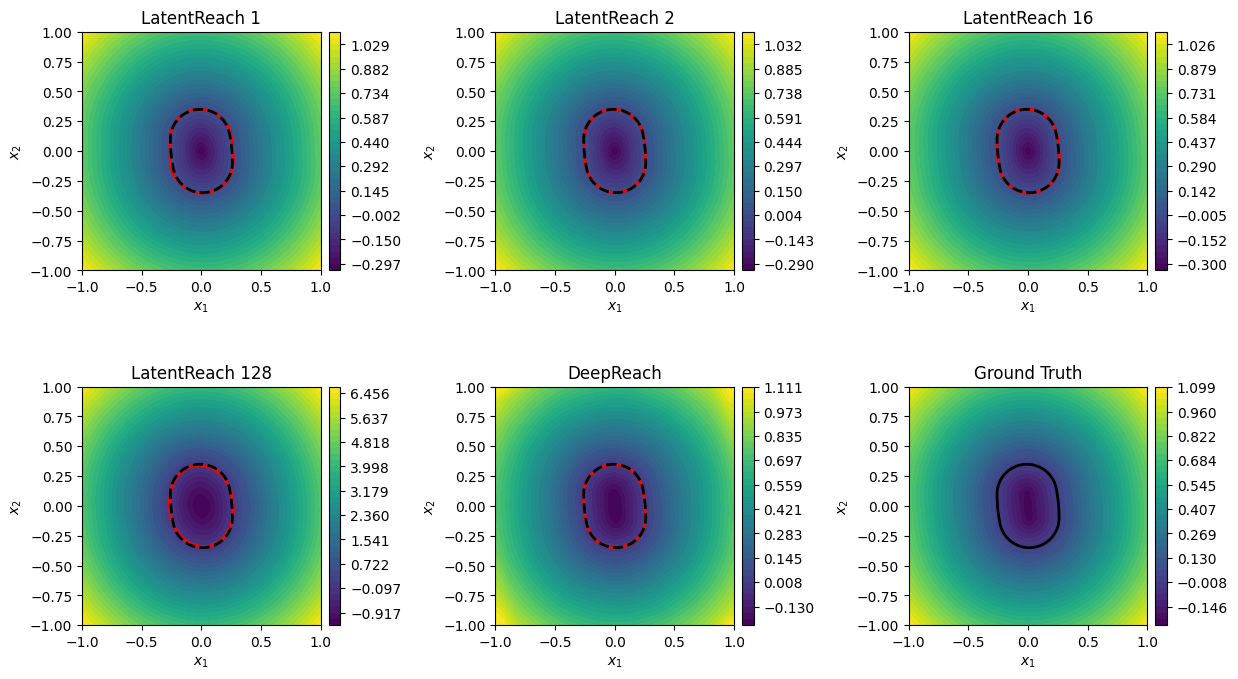

In [9]:
plot_pairwise_comparison(tau=0.2, nx=201)

In [35]:
metrics_df = make_metrics_table([1.00], nx=201)

combined_table = metrics_df.pivot(index="model", columns="tau", values=["MSE", "IoU"])

# optional: round for cleaner display
combined_table = combined_table.round({"MSE": 6, "IoU": 4})

display(combined_table)

latex_path = OUTPUT_DIR / "linear_oscillator_metrics_table.tex"

with open(latex_path, "w") as f:
    f.write(
        combined_table.to_latex(
            multicolumn=True,
            multirow=False,
            float_format="%.6f"
        )
    )

print("Saved:", latex_path)

100%|##################################|  1.0000/1.0 [00:00<00:00,  1.18sim_s/s]


,MSE,IoU
tau,1.0,1.0
model,,
DeepReach,0.000218,0.990180
LatentReach 1,0.002693,0.918747
LatentReach 128,92.260475,0.947495
LatentReach 16,0.000769,0.965684
LatentReach 2,0.000571,0.973666


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/linear_oscillator_metrics_table.tex


100%|##################|  0.0500/0.05000000074505806 [00:00<00:00,  4.76s/sim_s]
100%|##################|  0.1000/0.10000000149011612 [00:00<00:00,  4.90s/sim_s]
100%|##################|  0.2000/0.20000000298023224 [00:00<00:00,  4.41s/sim_s]
100%|###################|  0.4000/0.4000000059604645 [00:01<00:00,  4.72s/sim_s]
100%|####################|  0.7000/0.699999988079071 [00:02<00:00,  4.13s/sim_s]
100%|##################################|  1.0000/1.0 [00:04<00:00,  4.60s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/linear_oscillator_2d/notebook_outputs/brt_overlay_row.png


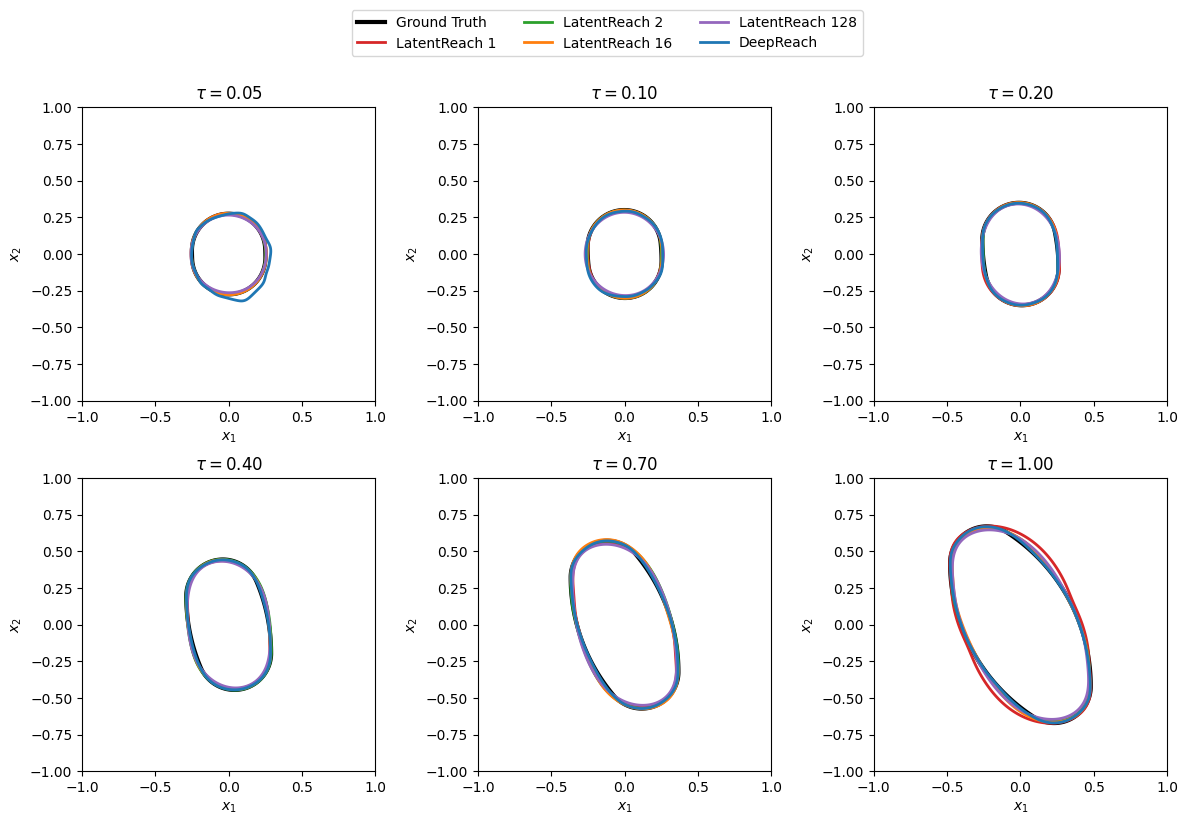

In [33]:
plot_zero_level_overlay_row(taus=[0.05, 0.10, 0.20, 0.40, 0.70, 1.00], nx=401)

In [21]:
# ============================================================
# AIR3D NOTEBOOK BLOCK
# Compare:
#   LatentReach (Staged)
#   LatentReach (Full Horizon)
#   LatentReach (Adaptive Sampling)
# against Ground Truth
# ============================================================

from pathlib import Path
from types import SimpleNamespace
import sys
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from torchdiffeq import odeint

REPO_ROOT = Path("/home/kendra/Code/Learning_Value_Function_Manifold")
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from lvfm.models import Decoder, PNODE, INR_PNODE
from lvfm.residuals import Air3DResidual
from lvfm.managers import LossManager
from lvfm.hj_solvers import solve_air3d_relative
from lvfm.plotting import build_air3d_gt_slice

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ----------------------------
# run locations
# ----------------------------
AIR_RUN_ROOT = REPO_ROOT / "scripts" / "runs" / "air_3d"

AIR_RUNS = {
    "LatentReach (Staged)": AIR_RUN_ROOT / "cnfrom2",
    "LatentReach (Full Horizon)": AIR_RUN_ROOT / "cnfrom2_full",
    "LatentReach (Adaptive Sampling)": AIR_RUN_ROOT / "cnfrom2_full_sampling",
    "LatentReach Bigger": AIR_RUN_ROOT / "cnfrom2_full-Copy4",
}

OUTPUT_DIR = AIR_RUN_ROOT / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Saving outputs to:", OUTPUT_DIR)

# ----------------------------
# helpers
# ----------------------------
def to_namespace(d):
    return SimpleNamespace(**d)

def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def load_cfg_from_run(run_dir):
    return to_namespace(load_yaml(Path(run_dir) / "config.yaml"))

def tau_ckpt_name(tau: float) -> str:
    if abs(float(tau)) < 1e-12:
        return "pretrain.pt"
    return f"tau_{float(tau):.2f}.pt"

def get_latest_step_ckpt(run_dir: Path):
    ckpt_dir = Path(run_dir) / "ckpts"
    step_ckpts = sorted(ckpt_dir.glob("step_*.pt"))
    if len(step_ckpts) == 0:
        return None
    return step_ckpts[-1]

def get_air3d_ckpt_path(display_name: str, tau: float):
    """
    Staged run: use matching tau checkpoint if available.
    Full/full-sampling runs: use latest step checkpoint.
    """
    run_dir = AIR_RUNS[display_name]
    ckpt_dir = run_dir / "ckpts"

    if display_name == "LatentReach (Staged)":
        ckpt_path = ckpt_dir / tau_ckpt_name(tau)
        if ckpt_path.exists():
            return ckpt_path
        # fallback to final staged checkpoint
        fallback = ckpt_dir / "tau_1.00.pt"
        if fallback.exists():
            return fallback
        return None

    # full-horizon / adaptive-sampling
    latest = get_latest_step_ckpt(run_dir)
    if latest is not None:
        return latest

    # fallback if someone saved a tau_1.00.pt instead
    fallback = ckpt_dir / "tau_1.00.pt"
    if fallback.exists():
        return fallback

    return None

def build_air3d_residual(cfg):
    return Air3DResidual(
        vp=cfg.vp,
        ve=cfg.ve,
        control_bound=cfg.u_bound,
        disturbance_bound=cfg.d_bound,
        radius=cfg.beta,
        T=cfg.T,
        x_bounds=cfg.x_bounds,
        y_bounds=cfg.y_bounds,
        psi_bounds=cfg.psi_bounds,
        scale_to_minus1_1=cfg.scale_to_minus1_1,
        scale_time_to_01=cfg.scale_time_to_01,
    )

def build_air3d_model(cfg, device=DEVICE):
    residual = build_air3d_residual(cfg)
    loss_manager = LossManager(
        residual=residual,
        loss_weights={"terminal": 1.0, "pinn": 1.0},
    )

    decoder = Decoder(
        hidden_dim=cfg.decoder_hidden_dim,
        latent_dim=cfg.latent_dim,
        coordinate_dim=cfg.coordinate_dim,
        out_dim=1,
        num_layers=cfg.decoder_num_layers,
        net_type=cfg.net_type,
        input_scale=cfg.input_scale,
    )

    pnode = PNODE(
        latent_dim=cfg.latent_dim,
        hidden_dim=cfg.pnode_hidden_dim,
    )

    model = INR_PNODE(
        latent_dim=cfg.latent_dim,
        decoder=decoder,
        pnode=pnode,
        loss_manager=loss_manager,
        value_var=0.5,
        value_normto=0.02,
        ode_solver=odeint,
        method=cfg.method,
        rtol=cfg.rtol,
        atol=cfg.atol,
        device=device,
    ).to(device)

    return model

def load_air3d_checkpoint(ckpt_path, device=DEVICE):
    ckpt_path = Path(ckpt_path)
    run_dir = ckpt_path.parent.parent
    cfg = load_cfg_from_run(run_dir)
    model = build_air3d_model(cfg, device=device)

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"], strict=True)
    model.eval()
    return model, cfg, ckpt

# ----------------------------
# evaluation on a 2D slice
# ----------------------------
def scale_air3d_states_to_net(x_phys, y_phys, psi_phys, cfg):
    x_net = x_phys.copy()
    y_net = y_phys.copy()
    psi_net = np.full_like(x_phys, psi_phys, dtype=np.float32)

    if cfg.scale_to_minus1_1:
        x_net = 2.0 * (x_phys - cfg.x_bounds[0]) / (cfg.x_bounds[1] - cfg.x_bounds[0]) - 1.0
        y_net = 2.0 * (y_phys - cfg.y_bounds[0]) / (cfg.y_bounds[1] - cfg.y_bounds[0]) - 1.0
        psi_net = psi_net / (1.2 * np.pi)

    return x_net, y_net, psi_net

@torch.no_grad()
def evaluate_air3d_on_slice(model, cfg, tau, psi_slice=None, nx=None, ny=None, device=DEVICE, chunk_size=4096):
    if psi_slice is None:
        psi_slice = cfg.psi_slice
    if nx is None:
        nx = cfg.x_discretization
    if ny is None:
        ny = cfg.y_discretization

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], nx, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], ny, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    x_flat = X.reshape(-1).astype(np.float32)
    y_flat = Y.reshape(-1).astype(np.float32)

    x_net, y_net, psi_net = scale_air3d_states_to_net(x_flat, y_flat, float(psi_slice), cfg)

    tau_net = np.full_like(x_flat, float(tau), dtype=np.float32)
    if cfg.scale_time_to_01:
        tau_net = tau_net / cfg.T

    xt_np = np.stack([x_net, y_net, psi_net, tau_net], axis=-1)

    vals = []
    for start in range(0, xt_np.shape[0], chunk_size):
        end = min(start + chunk_size, xt_np.shape[0])

        xt_chunk = torch.tensor(xt_np[start:end], dtype=torch.float32, device=device)
        tau_phys_chunk = torch.full((end - start,), float(tau), dtype=torch.float32, device=device)

        V_chunk = model.compute_value_at_xt(xt_chunk, tau_phys_chunk)[0]
        vals.append(V_chunk.reshape(-1).detach().cpu().numpy())

    V_pred = np.concatenate(vals, axis=0).reshape(ny, nx)
    return X, Y, V_pred

# ----------------------------
# ground truth
# ----------------------------
def compute_air3d_ground_truth_slice(tau=1.0, cfg=None):
    """
    Uses the same project solver as the training script, then slices with build_air3d_gt_slice.
    Robustly takes the LAST returned slice for the requested tau.
    """
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    gt = solve_air3d_relative(
        tau_steps=[float(tau)],
        xr_discretization=cfg.x_discretization,
        yr_discretization=cfg.y_discretization,
        theta_discretization=cfg.psi_discretization,
        xr_bounds=cfg.x_bounds,
        yr_bounds=cfg.y_bounds,
        theta_bounds=cfg.psi_bounds,
        vp=cfg.vp,
        ve=cfg.ve,
        u_bound=cfg.u_bound,
        d_bound=cfg.d_bound,
        radius=cfg.beta,
    )

    gt_slice = build_air3d_gt_slice(
        gt_values_3d=np.asarray(gt[-1]),
        psi_bounds=cfg.psi_bounds,
        psi_slice=cfg.psi_slice,
    )

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], cfg.x_discretization, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], cfg.y_discretization, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    return X, Y, gt_slice

# ----------------------------
# metrics
# ----------------------------
def compute_mse(V_pred, V_gt):
    return np.mean((V_pred - V_gt) ** 2)

def compute_iou(V_pred, V_gt):
    pred = V_pred <= 0
    gt = V_gt <= 0
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return inter / max(union, 1)

# ----------------------------
# evaluate all runs
# ----------------------------
def evaluate_all_air3d_models_for_tau(tau=1.0):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])
    X_gt, Y_gt, V_gt = compute_air3d_ground_truth_slice(tau=tau, cfg=cfg_ref)

    model_entries = []
    for display_name, run_dir in AIR_RUNS.items():
        ckpt_path = get_air3d_ckpt_path(display_name, tau)
        if ckpt_path is None:
            print(f"Skipping {display_name}: no checkpoint found")
            continue

        model, cfg, _ = load_air3d_checkpoint(ckpt_path, device=DEVICE)
        X, Y, V = evaluate_air3d_on_slice(
            model=model,
            cfg=cfg,
            tau=tau,
            psi_slice=cfg.psi_slice,
            nx=cfg.x_discretization,
            ny=cfg.y_discretization,
            device=DEVICE,
        )
        model_entries.append((display_name, X, Y, V))

    return cfg_ref, X_gt, Y_gt, V_gt, model_entries

# ----------------------------
# plots
# ----------------------------
def plot_air3d_comparison(tau=1.0, save=True):
    """
    2x2 grid:
      Row 1: Staged | Full Horizon
      Row 2: Adaptive Sampling | Ground Truth
    """
    cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=False)
    axes = axes.flatten()
    fig.subplots_adjust(hspace=0.12, wspace=0.45)

    # plot models
    for ax, (name, X, Y, V) in zip(axes[:len(model_entries)], model_entries):
        vmin = np.nanmin(V)
        vmax = np.nanmax(V)
        if np.isclose(vmin, vmax):
            vmax = vmin + 1e-6
        levels = np.linspace(vmin, vmax, 40)

        cf = ax.contourf(X, Y, V, levels=levels)
        ax.contour(X, Y, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

        ax.set_title(name, fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")
        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    # GT panel
    gt_ax = axes[-1]
    gt_vmin = np.nanmin(V_gt)
    gt_vmax = np.nanmax(V_gt)
    if np.isclose(gt_vmin, gt_vmax):
        gt_vmax = gt_vmin + 1e-6
    gt_levels = np.linspace(gt_vmin, gt_vmax, 40)

    cf = gt_ax.contourf(X_gt, Y_gt, V_gt, levels=gt_levels)
    gt_ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

    gt_ax.set_title("Ground Truth", fontsize=12)
    gt_ax.set_xlabel(r"$x_{\mathrm{rel}}$")
    gt_ax.set_ylabel(r"$y_{\mathrm{rel}}$")
    gt_ax.set_xlim(cfg_ref.x_bounds)
    gt_ax.set_ylim(cfg_ref.y_bounds)
    gt_ax.set_aspect("equal")
    fig.colorbar(cf, ax=gt_ax, fraction=0.046, pad=0.03)

    # fig.suptitle(f"Air3D slice at tau={tau:.2f}, psi={cfg_ref.psi_slice:.2f}", fontsize=16)

    if save:
        save_path = OUTPUT_DIR / f"air3d_pairwise_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

def plot_air3d_overlay_row(taus=[0.10, 0.30, 0.60, 1.00], save=True):
    """
    One row of BRT overlays across time.
    """
    colors = {
        "LatentReach (Staged)": "tab:red",
        "LatentReach (Full Horizon)": "tab:green",
        "LatentReach (Adaptive Sampling)": "tab:orange",
        "LatentReach Bigger": "tab:pink",
    }

    fig, axes = plt.subplots(1, len(taus), figsize=(4.5 * len(taus), 4.2), constrained_layout=False)
    if len(taus) == 1:
        axes = [axes]
    fig.subplots_adjust(top=0.78, wspace=0.30)


    legend_handles = [
        plt.Line2D([0], [0], color="black", lw=3.0, label="Ground Truth"),
        plt.Line2D([0], [0], color="tab:red", lw=2.0, label="LatentReach (Staged)"),
        plt.Line2D([0], [0], color="tab:green", lw=2.0, label="LatentReach (Full Horizon)"),
        plt.Line2D([0], [0], color="tab:orange", lw=2.0, label="LatentReach (Adaptive Sampling)"),
        plt.Line2D([0], [0], color="tab:orange", lw=2.0, label="LatentReach Bigger)"),
    ]

    for ax, tau in zip(axes, taus):
        cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)

        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=3.0)

        for name, X, Y, V in model_entries:
            ax.contour(X, Y, V, levels=[0.0], colors=colors[name], linewidths=2.0)

        ax.set_title(rf"$\tau={tau:.2f}$", fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")

    fig.legend(
            handles=legend_handles,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 0.99),
        )

    if save:
        save_path = OUTPUT_DIR / "air3d_brt_overlay_row.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

# ----------------------------
# tables
# ----------------------------
def make_air3d_metrics_table(taus=[0.10, 0.30, 0.60, 1.00]):
    rows = []
    for tau in taus:
        cfg_ref, X_gt, Y_gt, V_gt, model_entries = evaluate_all_air3d_models_for_tau(tau=tau)
        for name, X, Y, V in model_entries:
            rows.append({
                "tau": tau,
                "model": name,
                "MSE": compute_mse(V, V_gt),
                "IoU": compute_iou(V, V_gt),
            })
    return pd.DataFrame(rows)

def save_air3d_metrics_tables(taus=[0.10, 0.30, 0.60, 1.00]):
    metrics_df = make_air3d_metrics_table(taus=taus)

    csv_path = OUTPUT_DIR / "air3d_metrics.csv"
    metrics_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

    combined = metrics_df.pivot(index="model", columns="tau", values=["MSE", "IoU"])

    formatted = combined.copy()
    for col in formatted.columns:
        metric, tau = col
        if metric == "MSE":
            formatted[col] = formatted[col].map(lambda x: f"{x:.2e}")
        else:
            formatted[col] = formatted[col].map(lambda x: f"{x:.3f}")

    tex_path = OUTPUT_DIR / "air3d_metrics_table.tex"
    with open(tex_path, "w") as f:
        f.write(formatted.to_latex(escape=False, multicolumn=True, multirow=False))
    print("Saved:", tex_path)

    return metrics_df, combined, formatted

DEVICE: cuda
Saving outputs to: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs


100%|####################################################################################################################################################|  1.0000/1.0 [01:00<00:00, 60.30s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_pairwise_tau_1.00.png


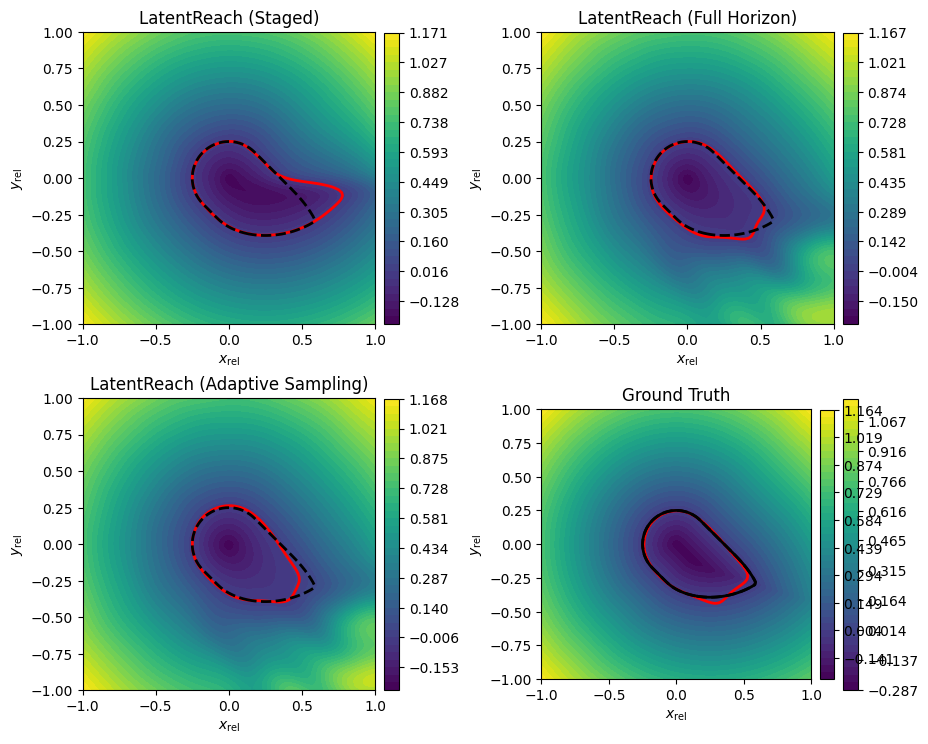

In [8]:
plot_air3d_comparison(tau=1.00, save=True)

100%|####################################################################################################################################|  0.1000/0.10000000149011612 [00:05<00:00, 59.17s/sim_s]
100%|####################################################################################################################################|  0.3000/0.30000001192092896 [00:18<00:00, 60.10s/sim_s]
100%|#####################################################################################################################################|  0.6000/0.6000000238418579 [00:36<00:00, 60.25s/sim_s]
100%|####################################################################################################################################################|  1.0000/1.0 [01:00<00:00, 60.99s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_brt_overlay_row.png


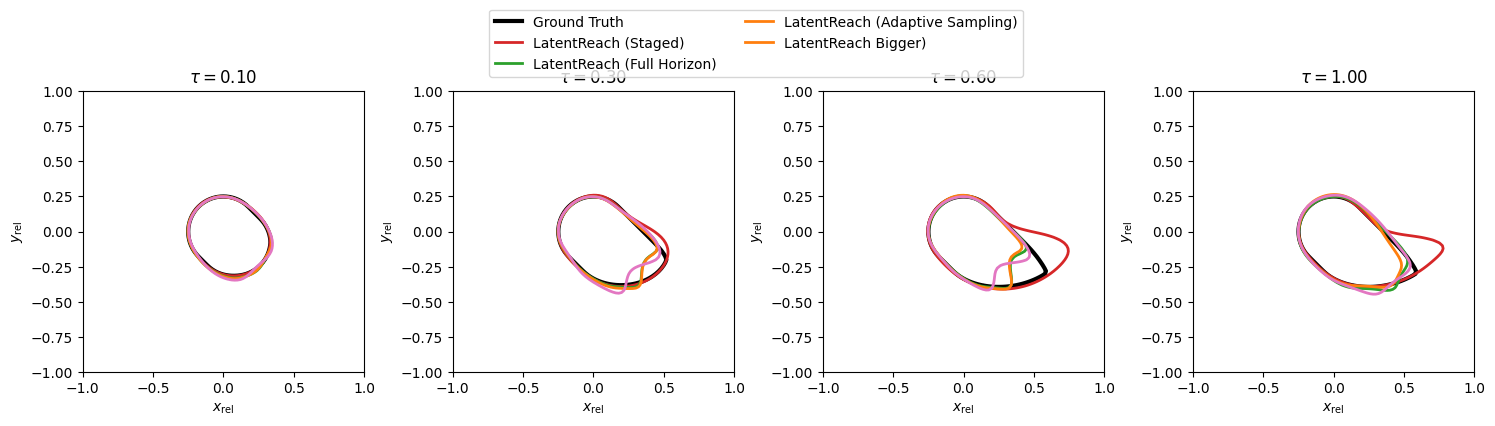

In [9]:
plot_air3d_overlay_row(taus=[0.10, 0.30, 0.60, 1.00], save=True)

In [12]:
combined = metrics_df.pivot(index="model", columns="tau", values=["MSE", "IoU"])

latex_path = OUTPUT_DIR / "metrics_table.tex"
with open(latex_path, "w") as f:
    f.write(
        combined.to_latex(
            escape=False,
            multicolumn=True,
            multirow=False,
            float_format="%.8f"
        )
    )

print("Saved:", latex_path)
display(combined)

NameError: name 'metrics_df' is not defined

In [11]:
# ============================================================
# AIR3D diagnostics:
#   3D gradient alignment
#   optimal control agreement
#   optimal disturbance agreement
# ============================================================

# ============================================================
# AIR3D ground-truth cache
# Prevents repeatedly running solve_air3d_relative(...)
# ============================================================

_AIR3D_GT_VOLUME_CACHE = {}

def air3d_cfg_cache_key(cfg):
    return (
        tuple(cfg.x_bounds),
        tuple(cfg.y_bounds),
        tuple(cfg.psi_bounds),
        int(cfg.x_discretization),
        int(cfg.y_discretization),
        int(cfg.psi_discretization),
        float(cfg.vp),
        float(cfg.ve),
        float(cfg.u_bound),
        float(cfg.d_bound),
        float(cfg.beta),
    )


def compute_air3d_ground_truth_volume_cached(tau=1.0, cfg=None, force_recompute=False):
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    key = (float(tau), air3d_cfg_cache_key(cfg))

    if (not force_recompute) and key in _AIR3D_GT_VOLUME_CACHE:
        print(f"Using cached Air3D ground truth for tau={tau:.2f}")
        return _AIR3D_GT_VOLUME_CACHE[key]

    print(f"Computing Air3D ground truth for tau={tau:.2f}")

    gt = solve_air3d_relative(
        tau_steps=[float(tau)],
        xr_discretization=cfg.x_discretization,
        yr_discretization=cfg.y_discretization,
        theta_discretization=cfg.psi_discretization,
        xr_bounds=cfg.x_bounds,
        yr_bounds=cfg.y_bounds,
        theta_bounds=cfg.psi_bounds,
        vp=cfg.vp,
        ve=cfg.ve,
        u_bound=cfg.u_bound,
        d_bound=cfg.d_bound,
        radius=cfg.beta,
    )

    gt_values_3d = np.asarray(gt[-1])
    _AIR3D_GT_VOLUME_CACHE[key] = gt_values_3d
    return gt_values_3d


def clear_air3d_ground_truth_cache():
    _AIR3D_GT_VOLUME_CACHE.clear()
    print("Cleared Air3D ground-truth cache.")
    
def finite_difference_xy_gradients(X, Y, V):
    """
    V shape is [y_index, x_index] because meshgrid(..., indexing="xy").
    np.gradient returns row derivative first, then column derivative:
        dV_dy, dV_dx
    """
    dx = float(X[0, 1] - X[0, 0])
    dy = float(Y[1, 0] - Y[0, 0])

    dV_dy, dV_dx = np.gradient(V, dy, dx, edge_order=2)
    return dV_dx, dV_dy


def air3d_psi_step(cfg):
    return float(cfg.psi_bounds[1] - cfg.psi_bounds[0]) / float(cfg.psi_discretization - 1)


def air3d_psi_neighbors(cfg, psi_slice=None, psi_step=None):
    if psi_slice is None:
        psi_slice = float(cfg.psi_slice)
    if psi_step is None:
        psi_step = air3d_psi_step(cfg)

    lo, hi = float(cfg.psi_bounds[0]), float(cfg.psi_bounds[1])

    psi_minus = max(lo, float(psi_slice) - psi_step)
    psi_plus = min(hi, float(psi_slice) + psi_step)

    if np.isclose(psi_plus, psi_minus):
        raise ValueError("psi_plus and psi_minus are equal; cannot estimate dV/dpsi.")

    return float(psi_minus), float(psi_slice), float(psi_plus)


def evaluate_air3d_model_slice_and_grads(
    model,
    cfg,
    tau,
    psi_slice=None,
    device=DEVICE,
    chunk_size=4096,
):
    """
    Evaluates V(x,y,psi,tau) on the requested psi slice and estimates:
        dV/dx, dV/dy from the 2D slice
        dV/dpsi from neighboring psi slices
    """
    psi_minus, psi0, psi_plus = air3d_psi_neighbors(cfg, psi_slice=psi_slice)

    X, Y, V0 = evaluate_air3d_on_slice(
        model=model,
        cfg=cfg,
        tau=tau,
        psi_slice=psi0,
        nx=cfg.x_discretization,
        ny=cfg.y_discretization,
        device=device,
        chunk_size=chunk_size,
    )

    _, _, V_minus = evaluate_air3d_on_slice(
        model=model,
        cfg=cfg,
        tau=tau,
        psi_slice=psi_minus,
        nx=cfg.x_discretization,
        ny=cfg.y_discretization,
        device=device,
        chunk_size=chunk_size,
    )

    _, _, V_plus = evaluate_air3d_on_slice(
        model=model,
        cfg=cfg,
        tau=tau,
        psi_slice=psi_plus,
        nx=cfg.x_discretization,
        ny=cfg.y_discretization,
        device=device,
        chunk_size=chunk_size,
    )

    dV_dx, dV_dy = finite_difference_xy_gradients(X, Y, V0)
    dV_dpsi = (V_plus - V_minus) / (psi_plus - psi_minus)

    grads = {
        "x": dV_dx,
        "y": dV_dy,
        "psi": dV_dpsi,
    }

    return X, Y, V0, grads


def compute_air3d_ground_truth_slice_and_grads_cached(
    tau=1.0,
    cfg=None,
    psi_slice=None,
    force_recompute=False,
):
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slice is None:
        psi_slice = float(cfg.psi_slice)

    psi_minus, psi0, psi_plus = air3d_psi_neighbors(cfg, psi_slice=psi_slice)

    gt_values_3d = compute_air3d_ground_truth_volume_cached(
        tau=tau,
        cfg=cfg,
        force_recompute=force_recompute,
    )

    V0 = build_air3d_gt_slice(
        gt_values_3d=gt_values_3d,
        psi_bounds=cfg.psi_bounds,
        psi_slice=psi0,
    )

    V_minus = build_air3d_gt_slice(
        gt_values_3d=gt_values_3d,
        psi_bounds=cfg.psi_bounds,
        psi_slice=psi_minus,
    )

    V_plus = build_air3d_gt_slice(
        gt_values_3d=gt_values_3d,
        psi_bounds=cfg.psi_bounds,
        psi_slice=psi_plus,
    )

    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], cfg.x_discretization, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], cfg.y_discretization, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")

    dV_dx, dV_dy = finite_difference_xy_gradients(X, Y, V0)
    dV_dpsi = (V_plus - V_minus) / (psi_plus - psi_minus)

    gt_grads = {
        "x": dV_dx,
        "y": dV_dy,
        "psi": dV_dpsi,
    }

    return X, Y, V0, gt_grads


def evaluate_all_air3d_models_with_gradients(tau=1.0, psi_slice=None):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slice is None:
        psi_slice = float(cfg_ref.psi_slice)

    X_gt, Y_gt, V_gt, gt_grads = compute_air3d_ground_truth_slice_and_grads_cached(
        tau=tau,
        cfg=cfg_ref,
        psi_slice=psi_slice,
    )

    model_entries = []

    for display_name, run_dir in AIR_RUNS.items():
        ckpt_path = get_air3d_ckpt_path(display_name, tau)
        if ckpt_path is None:
            print(f"Skipping {display_name}: no checkpoint found")
            continue

        model, cfg, _ = load_air3d_checkpoint(ckpt_path, device=DEVICE)

        X, Y, V, grads = evaluate_air3d_model_slice_and_grads(
            model=model,
            cfg=cfg,
            tau=tau,
            psi_slice=psi_slice,
            device=DEVICE,
        )

        model_entries.append((display_name, X, Y, V, grads))

    return cfg_ref, X_gt, Y_gt, V_gt, gt_grads, model_entries

def air3d_switching_functions(
    X,
    Y,
    grads,
    air3d_channel="d_minus_u",
):
    """
    Computes the switching functions for Air3D.

    Default assumes the common relative Air3D control terms:

        x_dot   contains + u * y
        y_dot   contains - u * x
        psi_dot contains d - u

    Therefore:

        g_u = y V_x - x V_y - V_psi
        g_d = V_psi

    If your residual instead uses psi_dot = u - d, set:

        air3d_channel="u_minus_d"
    """
    Vx = grads["x"]
    Vy = grads["y"]
    Vpsi = grads["psi"]

    if air3d_channel == "d_minus_u":
        g_u = Y * Vx - X * Vy - Vpsi
        g_d = Vpsi
    elif air3d_channel == "u_minus_d":
        g_u = Y * Vx - X * Vy + Vpsi
        g_d = -Vpsi
    else:
        raise ValueError("air3d_channel must be 'd_minus_u' or 'u_minus_d'.")

    return g_u, g_d


def bang_bang_policy_from_switching(g, bound, mode="min"):
    """
    If mode="min":
        a* = -bound * sign(g)

    If mode="max":
        a* = +bound * sign(g)
    """
    if mode == "min":
        return -bound * np.sign(g)
    elif mode == "max":
        return bound * np.sign(g)
    else:
        raise ValueError("mode must be 'min' or 'max'.")


def air3d_gradient_cosine(pred_grads, gt_grads, eps=1e-8):
    dot = (
        pred_grads["x"] * gt_grads["x"]
        + pred_grads["y"] * gt_grads["y"]
        + pred_grads["psi"] * gt_grads["psi"]
    )

    pred_norm = np.sqrt(
        pred_grads["x"] ** 2
        + pred_grads["y"] ** 2
        + pred_grads["psi"] ** 2
    )

    gt_norm = np.sqrt(
        gt_grads["x"] ** 2
        + gt_grads["y"] ** 2
        + gt_grads["psi"] ** 2
    )

    cos = dot / np.maximum(pred_norm * gt_norm, eps)
    return np.clip(cos, -1.0, 1.0)


def air3d_policy_agreement_stats(
    X,
    Y,
    pred_grads,
    gt_grads,
    u_bound,
    d_bound,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
    switch_deadzone=1e-3,
):
    pred_g_u, pred_g_d = air3d_switching_functions(
        X,
        Y,
        pred_grads,
        air3d_channel=air3d_channel,
    )

    gt_g_u, gt_g_d = air3d_switching_functions(
        X,
        Y,
        gt_grads,
        air3d_channel=air3d_channel,
    )

    u_pred = bang_bang_policy_from_switching(
        pred_g_u,
        u_bound,
        mode=control_mode,
    )
    u_gt = bang_bang_policy_from_switching(
        gt_g_u,
        u_bound,
        mode=control_mode,
    )

    d_pred = bang_bang_policy_from_switching(
        pred_g_d,
        d_bound,
        mode=disturbance_mode,
    )
    d_gt = bang_bang_policy_from_switching(
        gt_g_d,
        d_bound,
        mode=disturbance_mode,
    )

    valid_u = np.abs(gt_g_u) > switch_deadzone
    valid_d = np.abs(gt_g_d) > switch_deadzone

    u_agree = np.zeros_like(u_gt, dtype=bool)
    d_agree = np.zeros_like(d_gt, dtype=bool)

    u_agree[valid_u] = u_pred[valid_u] == u_gt[valid_u]
    d_agree[valid_d] = d_pred[valid_d] == d_gt[valid_d]

    return {
        "u_pred": u_pred,
        "u_gt": u_gt,
        "d_pred": d_pred,
        "d_gt": d_gt,
        "u_agree": u_agree,
        "d_agree": d_agree,
        "valid_u": valid_u,
        "valid_d": valid_d,
        "pred_g_u": pred_g_u,
        "gt_g_u": gt_g_u,
        "pred_g_d": pred_g_d,
        "gt_g_d": gt_g_d,
    }

def make_air3d_gradient_control_table(
    tau=1.0,
    psi_slice=None,
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
):
    cfg_ref, X_gt, Y_gt, V_gt, gt_grads, model_entries = evaluate_all_air3d_models_with_gradients(
        tau=tau,
        psi_slice=psi_slice,
    )

    rows = []
    near_boundary = np.abs(V_gt) <= near_boundary_band

    for name, X, Y, V, pred_grads in model_entries:
        cos = air3d_gradient_cosine(pred_grads, gt_grads)

        stats = air3d_policy_agreement_stats(
            X=X_gt,
            Y=Y_gt,
            pred_grads=pred_grads,
            gt_grads=gt_grads,
            u_bound=cfg_ref.u_bound,
            d_bound=cfg_ref.d_bound,
            control_mode=control_mode,
            disturbance_mode=disturbance_mode,
            air3d_channel=air3d_channel,
            switch_deadzone=switch_deadzone,
        )

        valid_u = stats["valid_u"]
        valid_d = stats["valid_d"]

        valid_u_boundary = np.logical_and(valid_u, near_boundary)
        valid_d_boundary = np.logical_and(valid_d, near_boundary)

        rows.append({
            "tau": tau,
            "model": name,
            "MSE": compute_mse(V, V_gt),
            "IoU": compute_iou(V, V_gt),
            "mean_grad_cos_3d": np.nanmean(cos),
            "mean_grad_cos_3d_near_boundary": np.nanmean(cos[near_boundary]),
            "control_agreement": np.mean(stats["u_agree"][valid_u]),
            "control_agreement_near_boundary": np.mean(stats["u_agree"][valid_u_boundary]),
            "disturbance_agreement": np.mean(stats["d_agree"][valid_d]),
            "disturbance_agreement_near_boundary": np.mean(stats["d_agree"][valid_d_boundary]),
            "num_valid_control": valid_u.sum(),
            "num_valid_control_near_boundary": valid_u_boundary.sum(),
            "num_valid_disturbance": valid_d.sum(),
            "num_valid_disturbance_near_boundary": valid_d_boundary.sum(),
        })

    return pd.DataFrame(rows)

def plot_air3d_gradient_alignment_comparison(
    tau=1.0,
    psi_slice=None,
    save=True,
):
    cfg_ref, X_gt, Y_gt, V_gt, gt_grads, model_entries = evaluate_all_air3d_models_with_gradients(
        tau=tau,
        psi_slice=psi_slice,
    )

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=False)
    axes = axes.flatten()
    fig.subplots_adjust(hspace=0.15, wspace=0.45)

    for ax, (name, X, Y, V, pred_grads) in zip(axes[:len(model_entries)], model_entries):
        cos = air3d_gradient_cosine(pred_grads, gt_grads)

        levels = np.linspace(-1.0, 1.0, 41)
        cf = ax.contourf(X_gt, Y_gt, cos, levels=levels, vmin=-1.0, vmax=1.0)

        ax.contour(X, Y, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

        ax.set_title(name, fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")

        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    gt_ax = axes[-1]
    gt_grad_norm = np.sqrt(
        gt_grads["x"] ** 2
        + gt_grads["y"] ** 2
        + gt_grads["psi"] ** 2
    )

    cf = gt_ax.contourf(X_gt, Y_gt, gt_grad_norm, levels=40)
    gt_ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

    gt_ax.set_title("GT 3D grad norm", fontsize=12)
    gt_ax.set_xlabel(r"$x_{\mathrm{rel}}$")
    gt_ax.set_ylabel(r"$y_{\mathrm{rel}}$")
    gt_ax.set_xlim(cfg_ref.x_bounds)
    gt_ax.set_ylim(cfg_ref.y_bounds)
    gt_ax.set_aspect("equal")

    fig.colorbar(cf, ax=gt_ax, fraction=0.046, pad=0.03)

    if save:
        save_path = OUTPUT_DIR / f"air3d_gradient_alignment_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()


def plot_air3d_near_boundary_policy_mismatch(
    tau=1.0,
    psi_slice=None,
    which="control",
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
    save=True,
):
    """
    which="control" plots u* mismatches.
    which="disturbance" plots d* mismatches.
    """
    if which not in ["control", "disturbance"]:
        raise ValueError("which must be 'control' or 'disturbance'.")

    cfg_ref, X_gt, Y_gt, V_gt, gt_grads, model_entries = evaluate_all_air3d_models_with_gradients(
        tau=tau,
        psi_slice=psi_slice,
    )

    near_boundary = np.abs(V_gt) <= near_boundary_band

    fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=False)
    axes = axes.flatten()
    fig.subplots_adjust(hspace=0.15, wspace=0.45)

    for ax, (name, X, Y, V, pred_grads) in zip(axes[:len(model_entries)], model_entries):
        stats = air3d_policy_agreement_stats(
            X=X_gt,
            Y=Y_gt,
            pred_grads=pred_grads,
            gt_grads=gt_grads,
            u_bound=cfg_ref.u_bound,
            d_bound=cfg_ref.d_bound,
            control_mode=control_mode,
            disturbance_mode=disturbance_mode,
            air3d_channel=air3d_channel,
            switch_deadzone=switch_deadzone,
        )

        if which == "control":
            agree = stats["u_agree"]
            valid = stats["valid_u"]
            label = "control"
        else:
            agree = stats["d_agree"]
            valid = stats["valid_d"]
            label = "disturbance"

        valid_boundary = np.logical_and(valid, near_boundary)
        mismatch = np.logical_and(np.logical_not(agree), valid_boundary)

        img = mismatch.astype(float)

        cf = ax.contourf(X_gt, Y_gt, img, levels=[-0.5, 0.5, 1.5])

        ax.contour(X, Y, V, levels=[0.0], colors="red", linewidths=2.0)
        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

        agreement = np.mean(agree[valid_boundary])

        ax.set_title(f"{name}\n{label} near-boundary agree={agreement:.3f}", fontsize=11)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")

        fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.03)

    axes[-1].axis("off")

    if save:
        save_path = OUTPUT_DIR / f"air3d_near_boundary_{which}_mismatch_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

In [16]:
df_air3d = make_air3d_gradient_control_table(
    tau=1.00,
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
)

display(df_air3d[[
    "model",
    "MSE",
    "IoU",
    "mean_grad_cos_3d",
    "mean_grad_cos_3d_near_boundary",
    "control_agreement",
    "control_agreement_near_boundary",
    "disturbance_agreement",
    "disturbance_agreement_near_boundary",
]])

plot_air3d_gradient_alignment_comparison(tau=1.00)

plot_air3d_near_boundary_policy_mismatch(
    tau=1.00,
    which="control",
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
)
tau=1.00,
    which="disturbance",
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
)

IndentationError: unexpected indent (2137266612.py, line 31)

In [17]:
# ============================================================
# AIR3D: plot multiple psi slices
# ============================================================

def make_air3d_xy_grid(cfg):
    x = np.linspace(cfg.x_bounds[0], cfg.x_bounds[1], cfg.x_discretization, dtype=np.float32)
    y = np.linspace(cfg.y_bounds[0], cfg.y_bounds[1], cfg.y_discretization, dtype=np.float32)
    X, Y = np.meshgrid(x, y, indexing="xy")
    return X, Y


def default_air3d_psi_slices(cfg, n_slices=5, avoid_edges=True, include_cfg_slice=True):
    """
    Returns several psi slices across cfg.psi_bounds.

    avoid_edges=True avoids exactly hitting the psi boundaries, which is useful
    if you later want finite differences in psi.
    """
    lo, hi = float(cfg.psi_bounds[0]), float(cfg.psi_bounds[1])

    if avoid_edges:
        dpsi = (hi - lo) / float(cfg.psi_discretization - 1)
        vals = np.linspace(lo + dpsi, hi - dpsi, n_slices)
    else:
        vals = np.linspace(lo, hi, n_slices)

    vals = [float(v) for v in vals]

    if include_cfg_slice:
        psi0 = float(cfg.psi_slice)
        if not any(np.isclose(psi0, v) for v in vals):
            vals.append(psi0)
            vals = sorted(vals)

    return vals


def compute_air3d_ground_truth_volume(tau=1.0, cfg=None):
    """
    Computes full 3D Air3D ground truth once for a requested tau.
    Then individual psi slices can be extracted cheaply.
    """
    if cfg is None:
        cfg = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    gt = solve_air3d_relative(
        tau_steps=[float(tau)],
        xr_discretization=cfg.x_discretization,
        yr_discretization=cfg.y_discretization,
        theta_discretization=cfg.psi_discretization,
        xr_bounds=cfg.x_bounds,
        yr_bounds=cfg.y_bounds,
        theta_bounds=cfg.psi_bounds,
        vp=cfg.vp,
        ve=cfg.ve,
        u_bound=cfg.u_bound,
        d_bound=cfg.d_bound,
        radius=cfg.beta,
    )

    return np.asarray(gt[-1])


def extract_air3d_gt_slice(gt_values_3d, cfg, psi_slice):
    return build_air3d_gt_slice(
        gt_values_3d=gt_values_3d,
        psi_bounds=cfg.psi_bounds,
        psi_slice=float(psi_slice),
    )


def load_all_air3d_models_for_tau(tau=1.0):
    """
    Loads each Air3D checkpoint once, so plotting many psi slices is faster.
    """
    loaded = []

    for display_name, run_dir in AIR_RUNS.items():
        ckpt_path = get_air3d_ckpt_path(display_name, tau)
        if ckpt_path is None:
            print(f"Skipping {display_name}: no checkpoint found")
            continue

        model, cfg, ckpt = load_air3d_checkpoint(ckpt_path, device=DEVICE)
        loaded.append((display_name, model, cfg, ckpt_path))

    return loaded

def plot_air3d_multi_psi_comparison(
    tau=1.0,
    psi_slices=None,
    n_slices=5,
    avoid_edges=True,
    save=True,
):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slices is None:
        psi_slices = default_air3d_psi_slices(
            cfg_ref,
            n_slices=n_slices,
            avoid_edges=avoid_edges,
            include_cfg_slice=True,
        )

    gt_values_3d = compute_air3d_ground_truth_volume(tau=tau, cfg=cfg_ref)
    X_gt, Y_gt = make_air3d_xy_grid(cfg_ref)

    loaded_models = load_all_air3d_models_for_tau(tau=tau)

    n_rows = len(psi_slices)
    n_cols = len(loaded_models) + 1  # models + GT

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.0 * n_cols, 3.5 * n_rows),
        squeeze=False,
        constrained_layout=False,
    )

    fig.subplots_adjust(hspace=0.25, wspace=0.35)

    col_titles = [name for name, _, _, _ in loaded_models] + ["Ground Truth"]

    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title, fontsize=12)

    for r, psi in enumerate(psi_slices):
        V_gt = extract_air3d_gt_slice(gt_values_3d, cfg_ref, psi)

        row_values = [V_gt]
        model_slices = []

        for name, model, cfg, ckpt_path in loaded_models:
            X, Y, V = evaluate_air3d_on_slice(
                model=model,
                cfg=cfg,
                tau=tau,
                psi_slice=psi,
                nx=cfg.x_discretization,
                ny=cfg.y_discretization,
                device=DEVICE,
            )
            model_slices.append((name, X, Y, V))
            row_values.append(V)

        row_vmin = min(np.nanmin(V) for V in row_values)
        row_vmax = max(np.nanmax(V) for V in row_values)
        if np.isclose(row_vmin, row_vmax):
            row_vmax = row_vmin + 1e-6

        levels = np.linspace(row_vmin, row_vmax, 40)

        # model panels
        for c, (name, X, Y, V) in enumerate(model_slices):
            ax = axes[r, c]
            cf = ax.contourf(X, Y, V, levels=levels)
            ax.contour(X, Y, V, levels=[0.0], colors="red", linewidths=2.0)
            ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linestyles="--", linewidths=2.0)

            ax.set_xlim(cfg_ref.x_bounds)
            ax.set_ylim(cfg_ref.y_bounds)
            ax.set_aspect("equal")
            ax.set_xlabel(r"$x_{\mathrm{rel}}$")
            ax.set_ylabel(r"$y_{\mathrm{rel}}$")

            if c == 0:
                ax.text(
                    0.02,
                    0.95,
                    rf"$\psi={psi:.2f}$",
                    transform=ax.transAxes,
                    va="top",
                    ha="left",
                    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
                )

        # GT panel
        ax = axes[r, -1]
        cf = ax.contourf(X_gt, Y_gt, V_gt, levels=levels)
        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=2.0)

        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")

        fig.colorbar(cf, ax=axes[r, :].tolist(), fraction=0.015, pad=0.02)

    if save:
        save_path = OUTPUT_DIR / f"air3d_multi_psi_comparison_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

def plot_air3d_multi_psi_brt_overlay(
    tau=1.0,
    psi_slices=None,
    n_slices=6,
    avoid_edges=True,
    save=True,
):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slices is None:
        psi_slices = default_air3d_psi_slices(
            cfg_ref,
            n_slices=n_slices,
            avoid_edges=avoid_edges,
            include_cfg_slice=True,
        )

    colors = {
        "LatentReach (Staged)": "tab:red",
        "LatentReach (Full Horizon)": "tab:green",
        "LatentReach (Adaptive Sampling)": "tab:orange",
    }

    gt_values_3d = compute_air3d_ground_truth_volume(tau=tau, cfg=cfg_ref)
    X_gt, Y_gt = make_air3d_xy_grid(cfg_ref)
    loaded_models = load_all_air3d_models_for_tau(tau=tau)

    n_cols = len(psi_slices)

    fig, axes = plt.subplots(
        1,
        n_cols,
        figsize=(4.2 * n_cols, 4.0),
        squeeze=False,
        constrained_layout=False,
    )
    axes = axes.flatten()

    fig.subplots_adjust(top=0.78, wspace=0.30)

    legend_handles = [
        plt.Line2D([0], [0], color="black", lw=3.0, label="Ground Truth"),
    ]

    for name, _, _, _ in loaded_models:
        legend_handles.append(
            plt.Line2D([0], [0], color=colors.get(name, "tab:blue"), lw=2.0, label=name)
        )

    for ax, psi in zip(axes, psi_slices):
        V_gt = extract_air3d_gt_slice(gt_values_3d, cfg_ref, psi)

        ax.contour(X_gt, Y_gt, V_gt, levels=[0.0], colors="black", linewidths=3.0)

        for name, model, cfg, ckpt_path in loaded_models:
            X, Y, V = evaluate_air3d_on_slice(
                model=model,
                cfg=cfg,
                tau=tau,
                psi_slice=psi,
                nx=cfg.x_discretization,
                ny=cfg.y_discretization,
                device=DEVICE,
            )

            ax.contour(
                X,
                Y,
                V,
                levels=[0.0],
                colors=colors.get(name, "tab:blue"),
                linewidths=2.0,
            )

        ax.set_title(rf"$\psi={psi:.2f}$", fontsize=12)
        ax.set_xlabel(r"$x_{\mathrm{rel}}$")
        ax.set_ylabel(r"$y_{\mathrm{rel}}$")
        ax.set_xlim(cfg_ref.x_bounds)
        ax.set_ylim(cfg_ref.y_bounds)
        ax.set_aspect("equal")

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.98),
    )

    if save:
        save_path = OUTPUT_DIR / f"air3d_multi_psi_brt_overlay_tau_{tau:.2f}.png"
        fig.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)

    plt.show()

def make_air3d_gradient_control_table_over_psi(
    tau=1.0,
    psi_slices=None,
    n_slices=7,
    avoid_edges=True,
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
):
    cfg_ref = load_cfg_from_run(AIR_RUNS["LatentReach (Staged)"])

    if psi_slices is None:
        psi_slices = default_air3d_psi_slices(
            cfg_ref,
            n_slices=n_slices,
            avoid_edges=avoid_edges,
            include_cfg_slice=True,
        )

    dfs = []

    for psi in psi_slices:
        print(f"Evaluating psi={psi:.4f}")

        df = make_air3d_gradient_control_table(
            tau=tau,
            psi_slice=psi,
            near_boundary_band=near_boundary_band,
            switch_deadzone=switch_deadzone,
            control_mode=control_mode,
            disturbance_mode=disturbance_mode,
            air3d_channel=air3d_channel,
        )

        df["psi"] = psi
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

100%|####################################################################################################################################################|  1.0000/1.0 [00:59<00:00, 59.47s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_multi_psi_comparison_tau_1.00.png


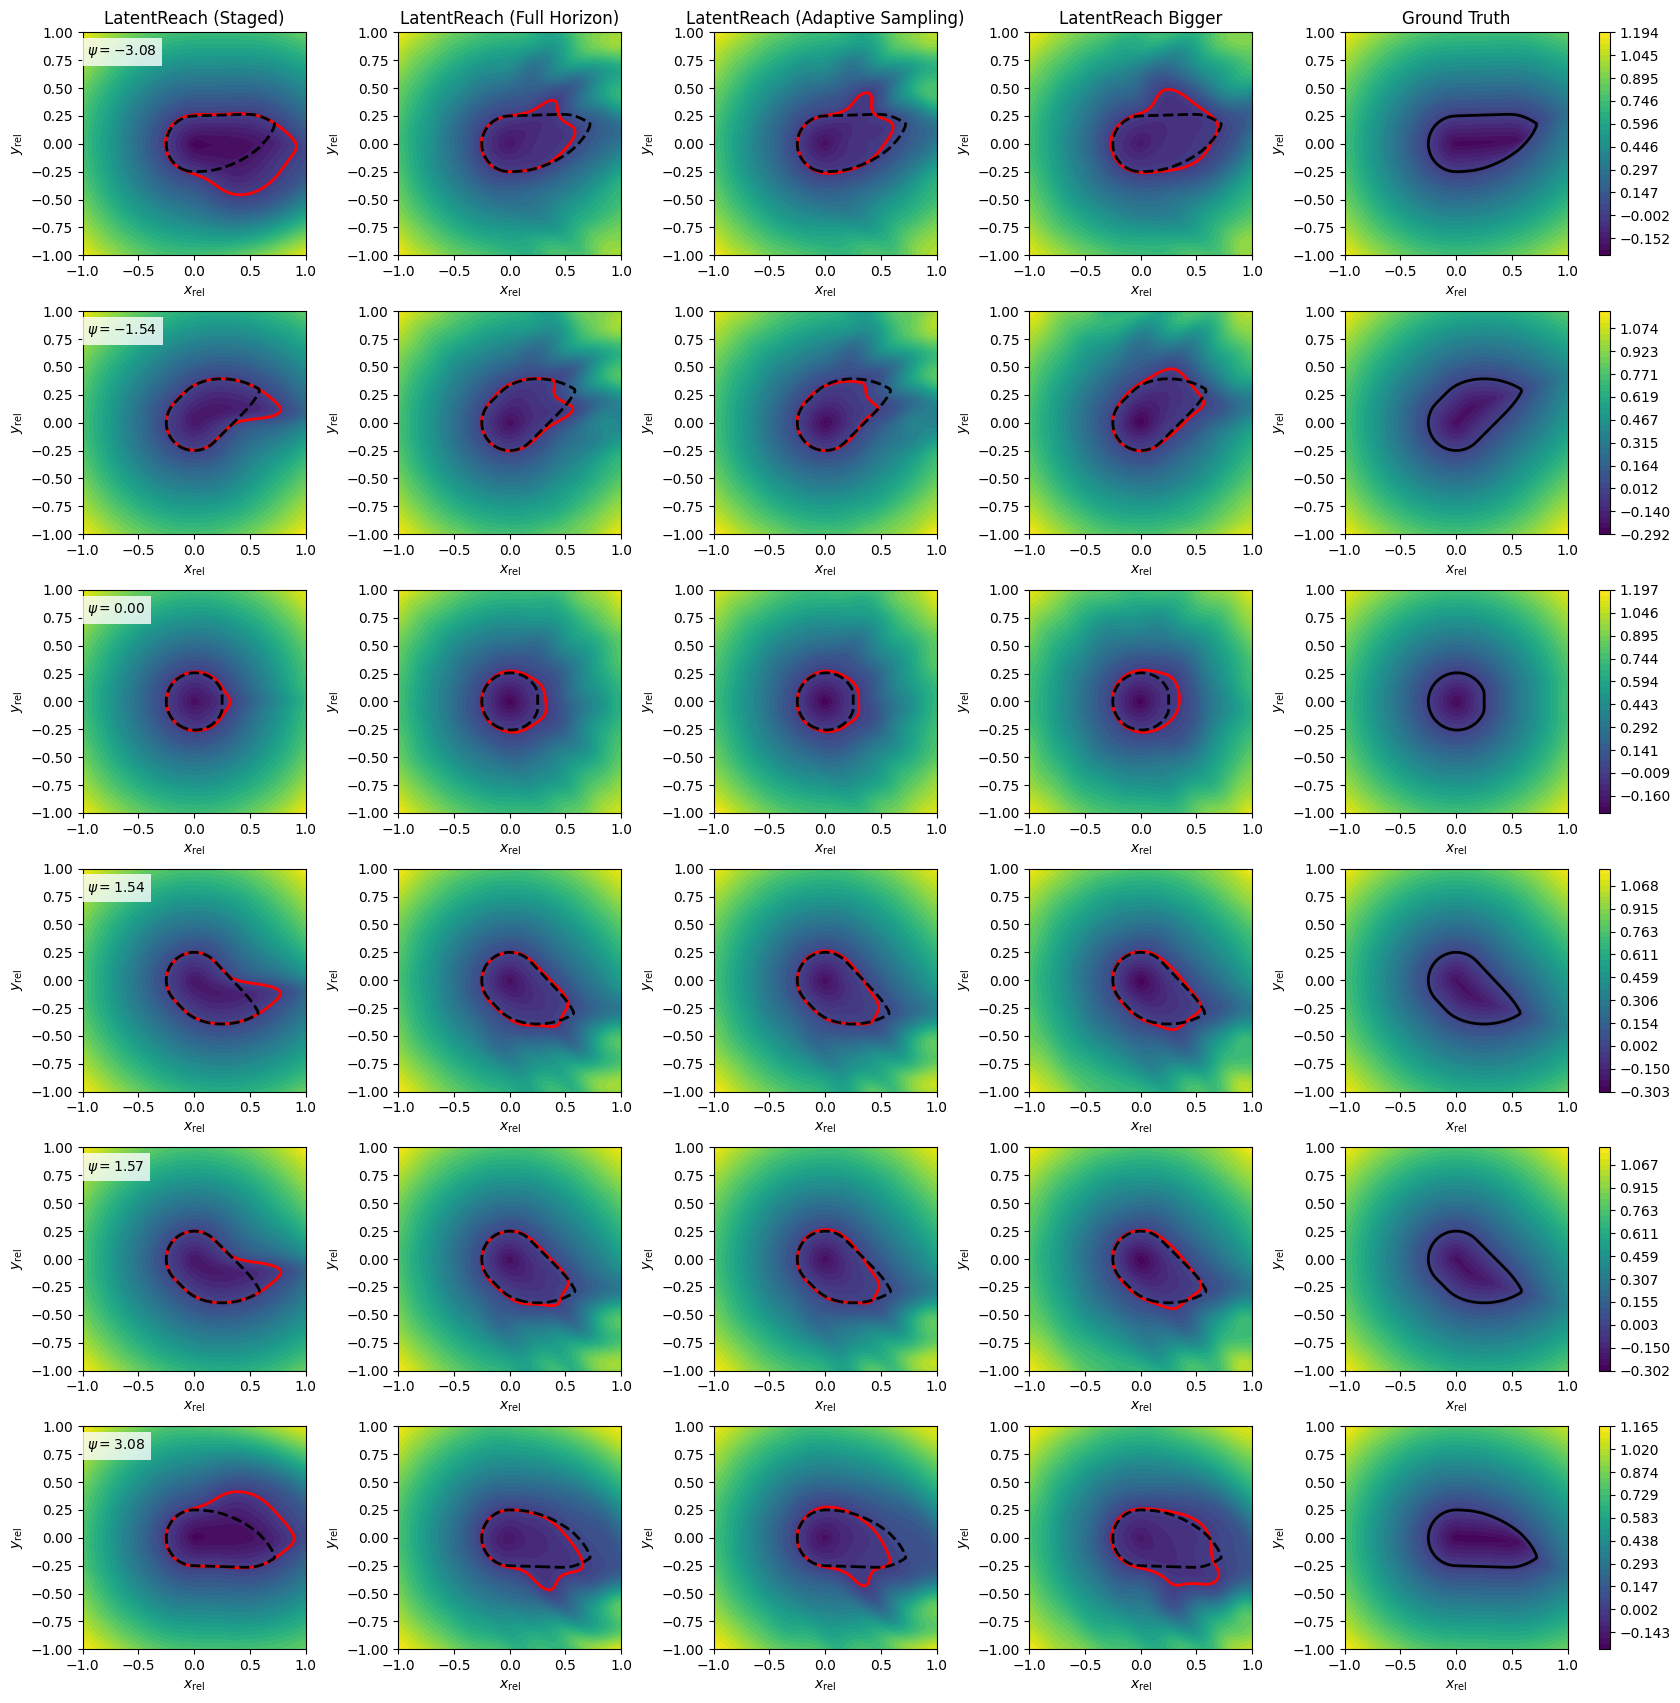

In [18]:
plot_air3d_multi_psi_comparison(
    tau=1.00,
    n_slices=5,
    avoid_edges=True,
)

100%|####################################################################################################################################################|  1.0000/1.0 [00:58<00:00, 58.76s/sim_s]


Saved: /home/kendra/Code/Learning_Value_Function_Manifold/scripts/runs/air_3d/notebook_outputs/air3d_multi_psi_brt_overlay_tau_1.00.png


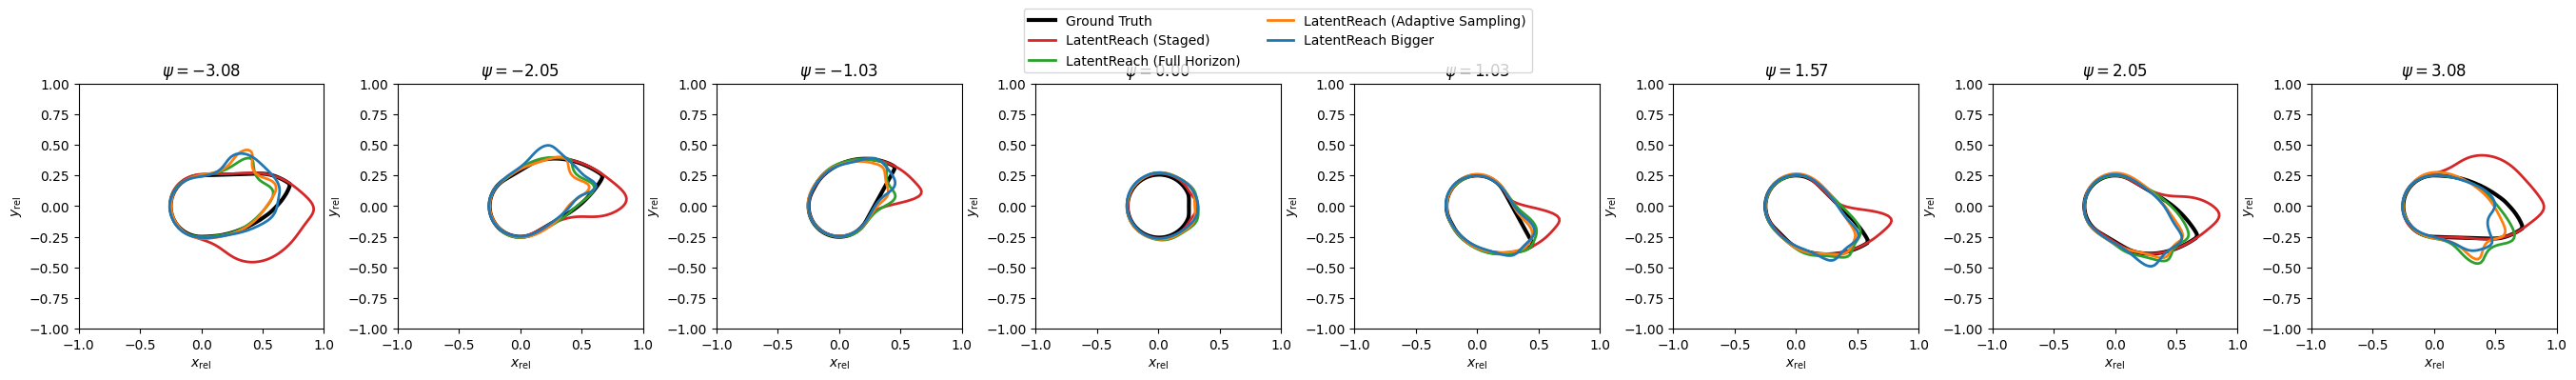

In [19]:
plot_air3d_multi_psi_brt_overlay(
    tau=1.00,
    n_slices=7,
    avoid_edges=True,
)

In [22]:
df_air3d_all_psi = make_air3d_gradient_control_table_over_psi(
    tau=1.00,
    n_slices=7,
    near_boundary_band=0.05,
    switch_deadzone=1e-3,
    control_mode="min",
    disturbance_mode="max",
    air3d_channel="d_minus_u",
)

display(df_air3d_all_psi[[
    "psi",
    "model",
    "MSE",
    "IoU",
    "mean_grad_cos_3d",
    "mean_grad_cos_3d_near_boundary",
    "control_agreement",
    "control_agreement_near_boundary",
    "disturbance_agreement",
    "disturbance_agreement_near_boundary",
]])

Evaluating psi=-3.0788
Using cached Air3D ground truth for tau=1.00
Evaluating psi=-2.0525
Using cached Air3D ground truth for tau=1.00
Evaluating psi=-1.0263
Using cached Air3D ground truth for tau=1.00
Evaluating psi=0.0000
Using cached Air3D ground truth for tau=1.00
Evaluating psi=1.0263
Using cached Air3D ground truth for tau=1.00
Evaluating psi=1.5708
Using cached Air3D ground truth for tau=1.00
Evaluating psi=2.0525
Using cached Air3D ground truth for tau=1.00
Evaluating psi=3.0788
Using cached Air3D ground truth for tau=1.00


,psi,model,MSE,IoU,mean_grad_cos_3d,mean_grad_cos_3d_near_boundary,control_agreement,control_agreement_near_boundary,disturbance_agreement,disturbance_agreement_near_boundary
0,-3.078761,LatentReach (Staged),0.012279,0.602041,0.963939,0.943510,0.926645,0.858896,0.895622,0.892063
1,-3.078761,LatentReach (Full Horizon),0.004139,0.820690,0.903630,0.933940,0.691248,0.849693,0.684519,0.809524
2,-3.078761,LatentReach (Adaptive Sampling),0.005477,0.813511,0.901527,0.947142,0.698816,0.907975,0.759382,0.933333
3,-3.078761,LatentReach Bigger,0.004165,0.808621,0.926667,0.958079,0.762468,0.901840,0.735731,0.755556
4,-2.052507,LatentReach (Staged),0.003140,0.799663,0.968390,0.949571,0.927336,0.923483,0.951847,0.948424
5,-2.052507,LatentReach (Full Horizon),0.004779,0.905295,0.930787,0.940338,0.767243,0.852243,0.838937,0.836676
6,-2.052507,LatentReach (Adaptive Sampling),0.006143,0.858031,0.934924,0.932993,0.788032,0.854881,0.834371,0.776504
7,-2.052507,LatentReach Bigger,0.004217,0.865546,0.941387,0.967910,0.744511,0.936675,0.836447,0.925501
8,-1.026254,LatentReach (Staged),0.002226,0.801724,0.960574,0.874311,0.894246,0.800000,0.907594,0.840909
9,-1.026254,LatentReach (Full Horizon),0.004290,0.891331,0.935513,0.948614,0.660381,0.863636,0.948343,0.993506


In [23]:
mag_all = gradient_magnitude_metrics(
    pred_grads,
    gt_grads,
    near_boundary=None,
)

mag_boundary = gradient_magnitude_metrics(
    pred_grads,
    gt_grads,
    near_boundary=near_boundary,
)

rows.append({
    "tau": tau,
    "model": name,
    "MSE": compute_mse(V, V_gt),
    "IoU": compute_iou(V, V_gt),
    "mean_grad_cos_3d": np.nanmean(cos),
    "mean_grad_cos_3d_near_boundary": np.nanmean(cos[near_boundary]),
    "grad_norm_ratio_median": mag_all["grad_norm_ratio_median"],
    "grad_norm_ratio_median_near_boundary": mag_boundary["grad_norm_ratio_median"],
    "grad_norm_rel_err": mag_all["grad_norm_rel_err"],
    "grad_norm_rel_err_near_boundary": mag_boundary["grad_norm_rel_err"],
    "control_agreement": np.mean(stats["u_agree"][valid_u]),
    "control_agreement_near_boundary": np.mean(stats["u_agree"][valid_u_boundary]),
    "disturbance_agreement": np.mean(stats["d_agree"][valid_d]),
    "disturbance_agreement_near_boundary": np.mean(stats["d_agree"][valid_d_boundary]),
})

display(df_air3d[[
    "model",
    "MSE",
    "IoU",
    "mean_grad_cos_3d_near_boundary",
    "grad_norm_ratio_median_near_boundary",
    "grad_norm_rel_err_near_boundary",
    "control_agreement_near_boundary",
    "disturbance_agreement_near_boundary",
]])

NameError: name 'gradient_magnitude_metrics' is not defined